# Customer Intelligence System — Step 4: Churn Model
**Question:** will this customer make *no* purchase in the next 90 days?

**Time-based design** (no peeking into the future):
```
 ... | train snapshots (4 cutoffs, 90 days apart) | test cutoff | 90-day label window | end of data
```
- Train on 4 past cutoffs (one is ~1 year before the test cutoff = same season)
- Tune on the latest train cutoff, test ONCE on the final cutoff
- Only customers active in the prior 365 days are scored (the long-gone are already lost)

In [1]:
# 4.1 Setup
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, roc_curve)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

sys.path.insert(0, str(Path("../src").resolve()))
from features import build_features, FEATURE_COLS
from churn import make_snapshot, holiday_flag, MODEL_COLS
from segmentation import seg_matrix

PROC, MODELS = Path("../data/processed"), Path("../models")
tx      = pd.read_parquet(PROC / "clean_retail.parquet")
cancels = pd.read_parquet(PROC / "cancellations.parquet")
pd.set_option("display.float_format", "{:,.3f}".format)

HORIZON, ACTIVE_WINDOW = 90, 365

In [2]:
# 4.2 Build snapshots + check seasonality
end_day     = tx["InvoiceDate"].max().normalize()
test_cutoff = end_day - pd.Timedelta(days=HORIZON)
train_cutoffs = [test_cutoff - pd.Timedelta(days=HORIZON * k) for k in range(4, 0, -1)]  # oldest first

snaps = {c: make_snapshot(tx, cancels, c, HORIZON, ACTIVE_WINDOW) for c in train_cutoffs + [test_cutoff]}

summary = pd.DataFrame({
    "customers":  [len(s) for s in snaps.values()],
    "churn_rate": [s["churned"].mean() for s in snaps.values()],
    "holiday_window": [s["holiday_window"].iat[0] for s in snaps.values()],
    "label window": [f"{c.date()} -> {(c + pd.Timedelta(days=HORIZON)).date()}" for c in snaps],
    "role": ["train"] * 3 + ["train (tuning val)", "TEST"],
}, index=[c.date() for c in snaps])
summary

,customers,churn_rate,holiday_window,label window,role
2010-09-15,3367,0.425,1,2010-09-15 -> 2010-12-14,train
2010-12-14,4210,0.694,0,2010-12-14 -> 2011-03-14,train
2011-03-14,4274,0.629,0,2011-03-14 -> 2011-06-12,train
2011-06-12,4317,0.639,0,2011-06-12 -> 2011-09-10,train (tuning val)
2011-09-10,4308,0.493,1,2011-09-10 -> 2011-12-09,TEST


In [3]:
# 4.3 Splits
train = pd.concat([snaps[c] for c in train_cutoffs])
test  = snaps[test_cutoff]
tune_tr  = pd.concat([snaps[c] for c in train_cutoffs[:-1]])
tune_val = snaps[train_cutoffs[-1]]

X_tr, y_tr = train[MODEL_COLS], train["churned"]
X_te, y_te = test[MODEL_COLS],  test["churned"]
print(f"train rows: {len(train):,} (churn {y_tr.mean():.1%}) | test rows: {len(test):,} (churn {y_te.mean():.1%})")

train rows: 16,168 (churn 60.6%) | test rows: 4,308 (churn 49.3%)


In [4]:
# 4.4 Evaluation helper
def evaluate(name, y, score, pred=None, thr=0.5):
    y = np.asarray(y); score = np.asarray(score)
    pred = (score >= thr).astype(int) if pred is None else np.asarray(pred)
    top = score >= np.quantile(score, 0.8)           # 20% riskiest customers
    return {"model": name,
            "ROC-AUC": roc_auc_score(y, score),
            "PR-AUC": average_precision_score(y, score),
            "precision": precision_score(y, pred), "recall": recall_score(y, pred), "F1": f1_score(y, pred),
            "top20% precision": y[top].mean(),        # of flagged, how many really churn
            "top20% recall": y[top].sum() / y.sum()}  # of all churners, how many we flag

# Baseline RULE: "no purchase in 60 days = churn" (score = recency itself)
baseline = evaluate("Rule: recency > 60d", y_te, X_te["recency_days"], pred=X_te["recency_days"] > 60)
pd.DataFrame([baseline]).set_index("model")

,ROC-AUC,PR-AUC,precision,recall,F1,top20% precision,top20% recall
model,,,,,,,
Rule: recency > 60d,0.707,0.658,0.611,0.805,0.694,0.711,0.293


In [5]:
# 4.5 Candidate models + tuning on the time-based validation split
def lr(C):   return make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(),
                                  LogisticRegression(C=C, max_iter=2000))
def rf(leaf): return make_pipeline(SimpleImputer(strategy="median", add_indicator=True),
                                   RandomForestClassifier(n_estimators=400, min_samples_leaf=leaf,
                                                          n_jobs=-1, random_state=42))
def xgb(d, lr_): return XGBClassifier(n_estimators=400, max_depth=d, learning_rate=lr_, subsample=0.8,
                                      colsample_bytree=0.8, eval_metric="logloss", random_state=42)

candidates = {
    ("Logistic Regression", "C=0.1"): lr(0.1),  ("Logistic Regression", "C=1"): lr(1.0),
    ("Random Forest", "leaf=10"): rf(10),        ("Random Forest", "leaf=30"): rf(30),
    ("XGBoost", "depth=3, lr=0.05"): xgb(3, .05), ("XGBoost", "depth=5, lr=0.05"): xgb(5, .05),
    ("XGBoost", "depth=3, lr=0.1"): xgb(3, .1),   ("XGBoost", "depth=5, lr=0.1"): xgb(5, .1),
}
rows = []
for (family, params), m in candidates.items():
    m.fit(tune_tr[MODEL_COLS], tune_tr["churned"])
    auc = roc_auc_score(tune_val["churned"], m.predict_proba(tune_val[MODEL_COLS])[:, 1])
    rows.append({"family": family, "params": params, "val ROC-AUC": auc})
tuning = pd.DataFrame(rows).sort_values("val ROC-AUC", ascending=False)
best = tuning.groupby("family").head(1).set_index("family")
display(tuning)
print("Best per family (chosen on VALIDATION, not test):"); display(best)

,family,params,val ROC-AUC
3,Random Forest,leaf=30,0.800
0,Logistic Regression,C=0.1,0.797
1,Logistic Regression,C=1,0.797
2,Random Forest,leaf=10,0.795
4,XGBoost,"depth=3, lr=0.05",0.794
6,XGBoost,"depth=3, lr=0.1",0.783
5,XGBoost,"depth=5, lr=0.05",0.781
7,XGBoost,"depth=5, lr=0.1",0.762


Best per family (chosen on VALIDATION, not test):


,params,val ROC-AUC
family,,
Random Forest,leaf=30,0.800
Logistic Regression,C=0.1,0.797
XGBoost,"depth=3, lr=0.05",0.794


In [6]:
# 4.6 Refit best-per-family on ALL train snapshots -> evaluate ONCE on test
final_models, results, scores = {}, [baseline], {"Rule: recency > 60d": X_te["recency_days"]}
for family, row in best.iterrows():
    m = candidates[(family, row["params"])]
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)[:, 1]
    final_models[family], scores[family] = m, p
    results.append(evaluate(f"{family} ({row['params']})", y_te, p))

report = pd.DataFrame(results).set_index("model")
display(report)
best_family = best["val ROC-AUC"].idxmax()
print(f"Chosen model (by validation): {best_family}  |  base churn rate on test: {y_te.mean():.1%}")

,ROC-AUC,PR-AUC,precision,recall,F1,top20% precision,top20% recall
model,,,,,,,
Rule: recency > 60d,0.707,0.658,0.611,0.805,0.694,0.711,0.293
Random Forest (leaf=30),0.763,0.721,0.617,0.907,0.735,0.749,0.304
Logistic Regression (C=0.1),0.759,0.706,0.632,0.854,0.726,0.747,0.303
"XGBoost (depth=3, lr=0.05)",0.759,0.709,0.620,0.906,0.736,0.735,0.299


Chosen model (by validation): Random Forest  |  base churn rate on test: 49.3%


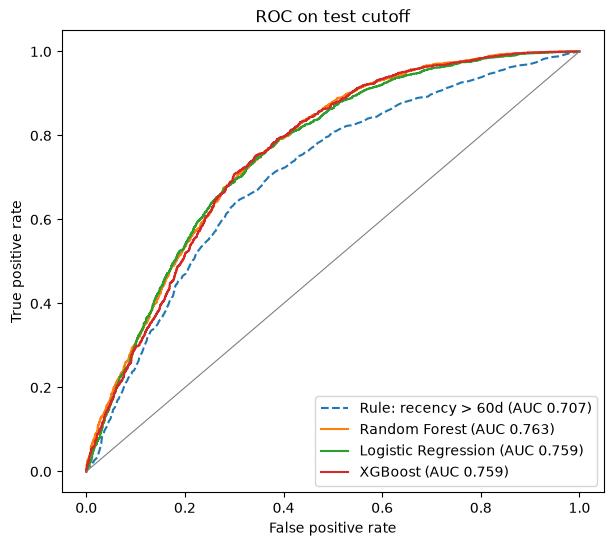

In [7]:
# 4.7 ROC curves
plt.figure(figsize=(7, 6))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_te, s)
    plt.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te, s):.3f})", ls="--" if name.startswith("Rule") else "-")
plt.plot([0, 1], [0, 1], color="grey", lw=0.8)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC on test cutoff")
plt.legend(); plt.show()

In [8]:
# 4.8 Risk deciles: does a higher score really mean more churn? (lift)
p_best = scores[best_family]
dec = pd.DataFrame({"score": p_best, "churned": y_te.to_numpy()})
dec["decile"] = pd.qcut(dec["score"].rank(method="first"), 10, labels=range(10, 0, -1))  # 1 = riskiest
lift = dec.groupby("decile", observed=True).agg(customers=("churned", "size"), churn_rate=("churned", "mean"),
                                                avg_score=("score", "mean")).sort_index(ascending=False)
lift["lift vs avg"] = lift["churn_rate"] / y_te.mean()
lift

,customers,churn_rate,avg_score,lift vs avg
decile,,,,
1,431,0.780,0.889,1.582
2,431,0.719,0.843,1.460
3,431,0.698,0.811,1.417
4,430,0.653,0.780,1.326
5,431,0.603,0.732,1.224
6,431,0.485,0.661,0.984
7,430,0.447,0.570,0.906
8,431,0.309,0.467,0.626
9,431,0.174,0.316,0.353


In [9]:
# 4.9 Churn rate by segment at the test cutoff (validates Step 3)
seg = joblib.load(MODELS / "segmentation.joblib")
test_seg = seg["kmeans"].predict(seg["scaler"].transform(seg_matrix(test)))
seg_view = pd.DataFrame({"segment": pd.Series(test_seg).map(seg["segment_names"]).to_numpy(),
                         "churned": y_te.to_numpy(), "score": p_best})
seg_view.groupby("segment").agg(customers=("churned", "size"), actual_churn=("churned", "mean"),
                                predicted=("score", "mean")).sort_values("actual_churn")

,customers,actual_churn,predicted
segment,,,
Champions,678,0.136,0.212
Loyal Regulars,1400,0.391,0.538
New & Occasional,1266,0.638,0.759
Lapsed Regulars,691,0.661,0.809
Lost One-timers,273,0.802,0.883


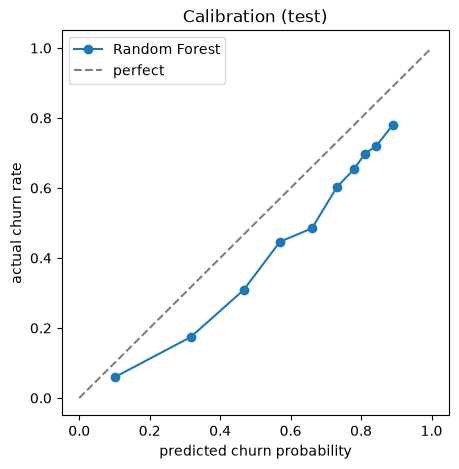

In [10]:
# 4.10 Calibration: when the model says 70%, do ~70% churn? (the dashboard shows these numbers)
frac_pos, mean_pred = calibration_curve(y_te, p_best, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 5))
plt.plot(mean_pred, frac_pos, "o-", label=best_family); plt.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
plt.xlabel("predicted churn probability"); plt.ylabel("actual churn rate"); plt.title("Calibration (test)")
plt.legend(); plt.show()

In [11]:
# 4.10b Did the seasonal feature fix calibration? Same model family, with vs without it
from sklearn.metrics import brier_score_loss
params = best.loc[best_family, "params"]
cmp = []
for label, cols in [("without holiday_window", FEATURE_COLS), ("with holiday_window", FEATURE_COLS + ["holiday_window"])]:
    m = candidates[(best_family, params)]
    m.fit(train[cols], y_tr)
    p = m.predict_proba(test[cols])[:, 1]
    cmp.append({"version": label, "ROC-AUC": roc_auc_score(y_te, p), "Brier (lower=better)": brier_score_loss(y_te, p),
                "avg predicted": p.mean(), "actual churn": y_te.mean()})
pd.DataFrame(cmp).set_index("version")

,ROC-AUC,Brier (lower=better),avg predicted,actual churn
version,,,,
without holiday_window,0.763,0.212,0.617,0.493
with holiday_window,0.761,0.199,0.467,0.493


In [12]:
# 4.11 Final model: refit on ALL labelled snapshots (train + test), score customers TODAY
all_snaps = pd.concat(snaps.values())
final = candidates[(best_family, best.loc[best_family, "params"])]
final.fit(all_snaps[MODEL_COLS], all_snaps["churned"])

current = pd.read_parquet(PROC / "customers_segmented.parquet")
now = end_day + pd.Timedelta(days=1)
active = current["recency_days"] <= ACTIVE_WINDOW
current["holiday_window"] = holiday_flag(now, HORIZON)   # today's window: Dec -> Mar = 0
current["churn_prob"] = np.nan
current.loc[active, "churn_prob"] = final.predict_proba(current.loc[active, MODEL_COLS])[:, 1]

current["risk_band"] = "Already lost"
current.loc[active, "risk_band"] = pd.qcut(current.loc[active, "churn_prob"].rank(method="first"),
                                           [0, .40, .75, 1.0], labels=["Low", "Medium", "High"]).astype(str)

last_year = tx[tx["InvoiceDate"] >= now - pd.Timedelta(days=365)]
current["annual_value"] = last_year.groupby("Customer ID")["Revenue"].sum().reindex(current.index).fillna(0)
current["value_at_risk"] = (current["churn_prob"] * current["annual_value"]).fillna(0)

print(current["risk_band"].value_counts())
print(f"\nTotal annual value at risk: £{current['value_at_risk'].sum():,.0f}")
current.sort_values("value_at_risk", ascending=False)[
    ["segment", "key_account", "recency_days", "frequency", "annual_value", "churn_prob", "value_at_risk"]].head(10)

risk_band
Low             1705
Already lost    1578
Medium          1491
High            1065
Name: count, dtype: int64

Total annual value at risk: £1,720,435


,segment,key_account,recency_days,frequency,annual_value,churn_prob,value_at_risk
Customer ID,,,,,,,
15749,Loyal Regulars,1,235,2,"24,850.900",0.679,"16,863.078"
16029,Champions,0,38,103,"56,098.410",0.188,"10,520.821"
14096,Champions,0,4,17,"53,258.430",0.147,"7,810.594"
12590,Loyal Regulars,1,211,1,"9,341.260",0.814,"7,601.464"
16000,Loyal Regulars,0,2,3,"12,393.700",0.507,"6,284.120"
12415,Champions,1,24,23,"123,806.880",0.049,"6,096.047"
14156,Champions,1,9,143,"113,544.080",0.054,"6,075.897"
12753,Champions,0,22,6,"21,327.390",0.266,"5,673.386"
17450,Champions,1,8,49,"187,578.690",0.029,"5,414.716"


In [13]:
# 4.12 Save
current.to_parquet(PROC / "customers_scored.parquet")
joblib.dump({"model": final, "family": best_family, "features": MODEL_COLS, "horizon": HORIZON,
             "active_window": ACTIVE_WINDOW, "test_report": report,
             "cutoffs": [c.date() for c in snaps]}, MODELS / "churn_model.joblib")
print("saved customers_scored.parquet", current.shape, "+ models/churn_model.joblib")

saved customers_scored.parquet (5839, 33) + models/churn_model.joblib
